<a href="https://colab.research.google.com/github/JourdynLuv/JourdynLuv/blob/main/Razai_Khalid_2_3_Visualizing_Relationships_Between_Categorical_Features_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [12]:
import pandas as pd

df = pd.read_csv('/content/sample_data/titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [13]:
df['Fare'].describe()

,Fare
count,891.000000
mean,32.204208
std,49.693429
min,0.000000
25%,7.910400
50%,14.454200
75%,31.000000
max,512.329200


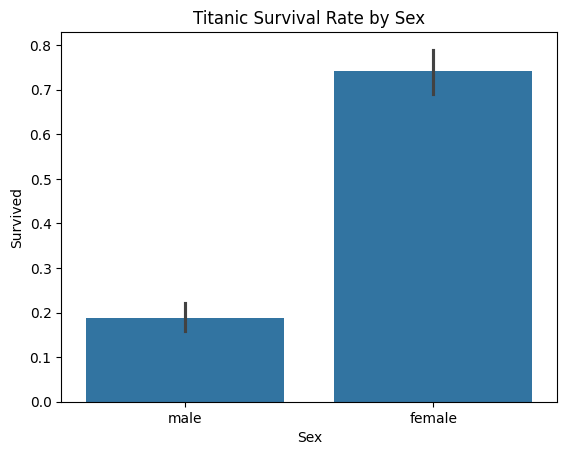

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Sex', y='Survived', data=df)
plt.title('Titanic Survival Rate by Sex')
plt.show()

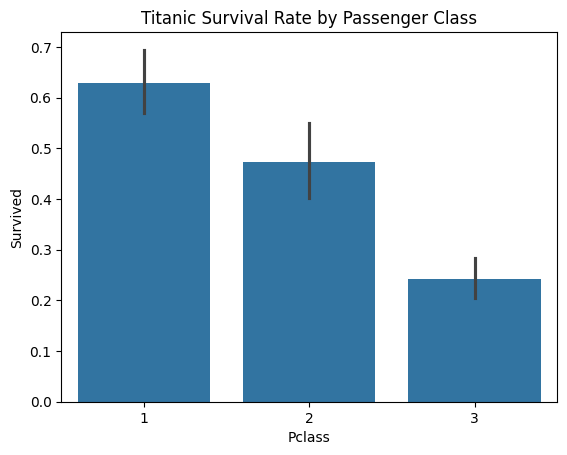

In [15]:
sns.barplot(x='Pclass', y='Survived', data=df)
plt.title('Titanic Survival Rate by Passenger Class')
plt.show()

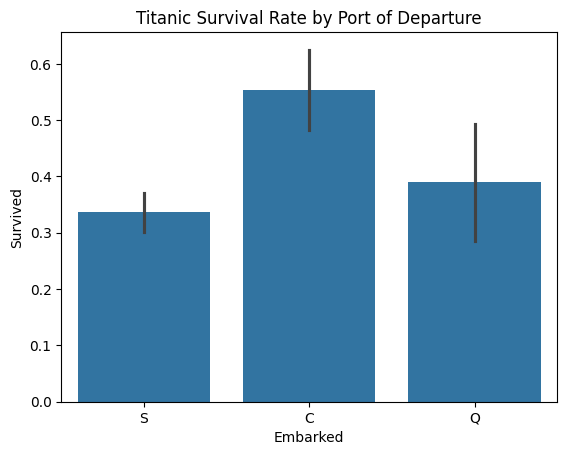

In [16]:
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title('Titanic Survival Rate by Port of Departure')
plt.show()

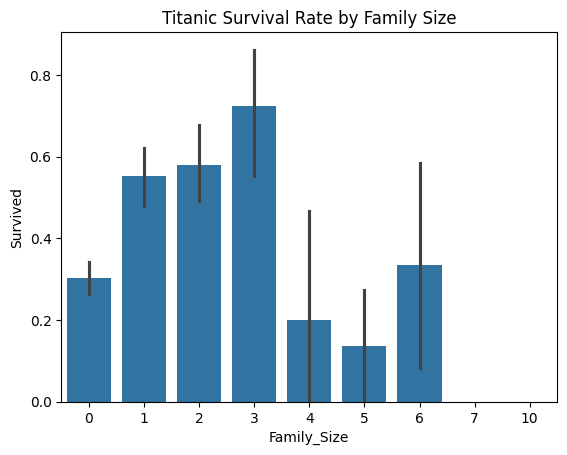

In [17]:
df['Family_Size'] = df['SibSp'] + df['Parch']

sns.barplot(x='Family_Size', y='Survived', data=df)
plt.title('Titanic Survival Rate by Family Size')
plt.show()

In [18]:
survivors = df[(df['Sex'] == 'female') &
               (df['Pclass'] == 1) &
               (df['Embarked'] == 'C') &
               (df['Family_Size'].between(1, 3))]

print("--- MOST LIKELY TO SURVIVE ---")
print(survivors['Name'].head(5))

print("\n")

doomed = df[(df['Sex'] == 'male') &
            (df['Pclass'] == 3) &
            (df['Embarked'] == 'S') &
            (df['Family_Size'] == 0)]

print("--- LEAST LIKELY TO SURVIVE ---")
print(doomed['Name'].head(5))

--- MOST LIKELY TO SURVIVE ---
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
31        Spencer, Mrs. William Augustus (Marie Eugenie)
52              Harper, Mrs. Henry Sleeper (Myna Haxtun)
215                              Newell, Miss. Madeleine
291              Bishop, Mrs. Dickinson H (Helen Walton)
Name: Name, dtype: object


--- LEAST LIKELY TO SURVIVE ---
4           Allen, Mr. William Henry
12    Saundercock, Mr. William Henry
29               Todoroff, Mr. Lalio
37          Cann, Mr. Ernest Charles
45          Rogers, Mr. William John
Name: Name, dtype: object


Myna Harper and her Husband Henry survived on Lifeboat 3 -  they also managed to bring their dog with them. The dog was brought on without anyone objecting as well as bringing an Egyption interpreter.

William Henry Hallen was a toolmaker who was on the ship. He was a 3rd class passanger who was traveling alone to America to find work so he could send money to his wife to join hime later. He sadly did not survive and his body was never found but 88 years after the wreck they found his suitcase and his clothes were still inside.